In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings("ignore")

In [2]:
## Load Phase 1 outputs
port_ts = pd.read_csv('../outputs/processed/port_activity_top20.csv', index_col='date', parse_dates=True)
pde_df = pd.read_csv('../outputs/processed/pde_flags.csv', index_col='date', parse_dates=True)
top_ports = port_ts.columns.to_list()
top_ports

['Antwerp',
 'Busan',
 'Chiba',
 'Guangzhou (Nansha)',
 'Gwangyang (Kwangyang)',
 'Hong Kong',
 'Kaohsiung',
 'Kobe',
 'Mizushima',
 'Nagoya',
 'Ningbo',
 'Port Klang',
 'Qingdao',
 'Rotterdam',
 'Sakai-Semboku',
 'Shanghai (Pudong)',
 'Singapore',
 'Tianjin Xin Gang',
 'Ulsan',
 'Yokohama']

In [3]:
print(f"Port activity shape: {port_ts.shape}")
print(f"PDE flags shape:  {pde_df.shape}")
print(f"Date Range: {port_ts.index.min()} -> {port_ts.index.max()}")
print(f"\nTop 20 ports loaded successfully.")

Port activity shape: (2594, 20)
PDE flags shape:  (2594, 20)
Date Range: 2019-01-01 00:00:00 -> 2026-02-06 00:00:00

Top 20 ports loaded successfully.


In [4]:
## Data Preprocessing
# Check time index continuity
expected_days = pd.date_range(port_ts.index.min(), port_ts.index.max(), freq='D')
missing_dates = expected_days.difference(port_ts.index)
print(f"Missing dates in index: {len(missing_dates)}")

# Check missing values per port
print(f"\nMissing values per port:")
print(port_ts.isna().sum().sort_values(ascending=False).head(10))

Missing dates in index: 0

Missing values per port:
Antwerp                  0
Busan                    0
Chiba                    0
Guangzhou (Nansha)       0
Gwangyang (Kwangyang)    0
Hong Kong                0
Kaohsiung                0
Kobe                     0
Mizushima                0
Nagoya                   0
dtype: int64


* If variance is unstable, a log transformation can stabilise it.
* ARIMA assumes variance is roughly constant throughout the series. If it isn't, the model's error estimates become unreliable.
* The raw series plots from Phase 1 showed that variance is relatively stable across time for all ports — there is no period where fluctuations are dramatically larger or smaller than others. So log transformation is not needed here.

In [5]:
## Adfuller test.
# p<0.05 -> stationary -> d=0 else d>=1
adf = []

for port in top_ports:
    series = port_ts[port].dropna()
    p = adfuller(series)[1]               ## [0] - test statistic, [1] - p-value, [2] - number of lags used, etc.
    d = 0 if p < 0.05 else 1

    adf.append({'port': port, 'p': round(p, 4), 'd': d})
    print(f"{port:<25} p={p:.4f}  d={d}")

adf_df = pd.DataFrame(adf)

Antwerp                   p=0.0008  d=0
Busan                     p=0.0001  d=0
Chiba                     p=0.0000  d=0
Guangzhou (Nansha)        p=0.0003  d=0
Gwangyang (Kwangyang)     p=0.5808  d=1
Hong Kong                 p=0.0001  d=0
Kaohsiung                 p=0.0012  d=0
Kobe                      p=0.0000  d=0
Mizushima                 p=0.0000  d=0
Nagoya                    p=0.0000  d=0
Ningbo                    p=0.0552  d=1
Port Klang                p=0.0019  d=0
Qingdao                   p=0.0000  d=0
Rotterdam                 p=0.0058  d=0
Sakai-Semboku             p=0.0000  d=0
Shanghai (Pudong)         p=0.0015  d=0
Singapore                 p=0.0169  d=0
Tianjin Xin Gang          p=0.0000  d=0
Ulsan                     p=0.0635  d=1
Yokohama                  p=0.0000  d=0


* So 17 ports are stationary. 3 need differencing

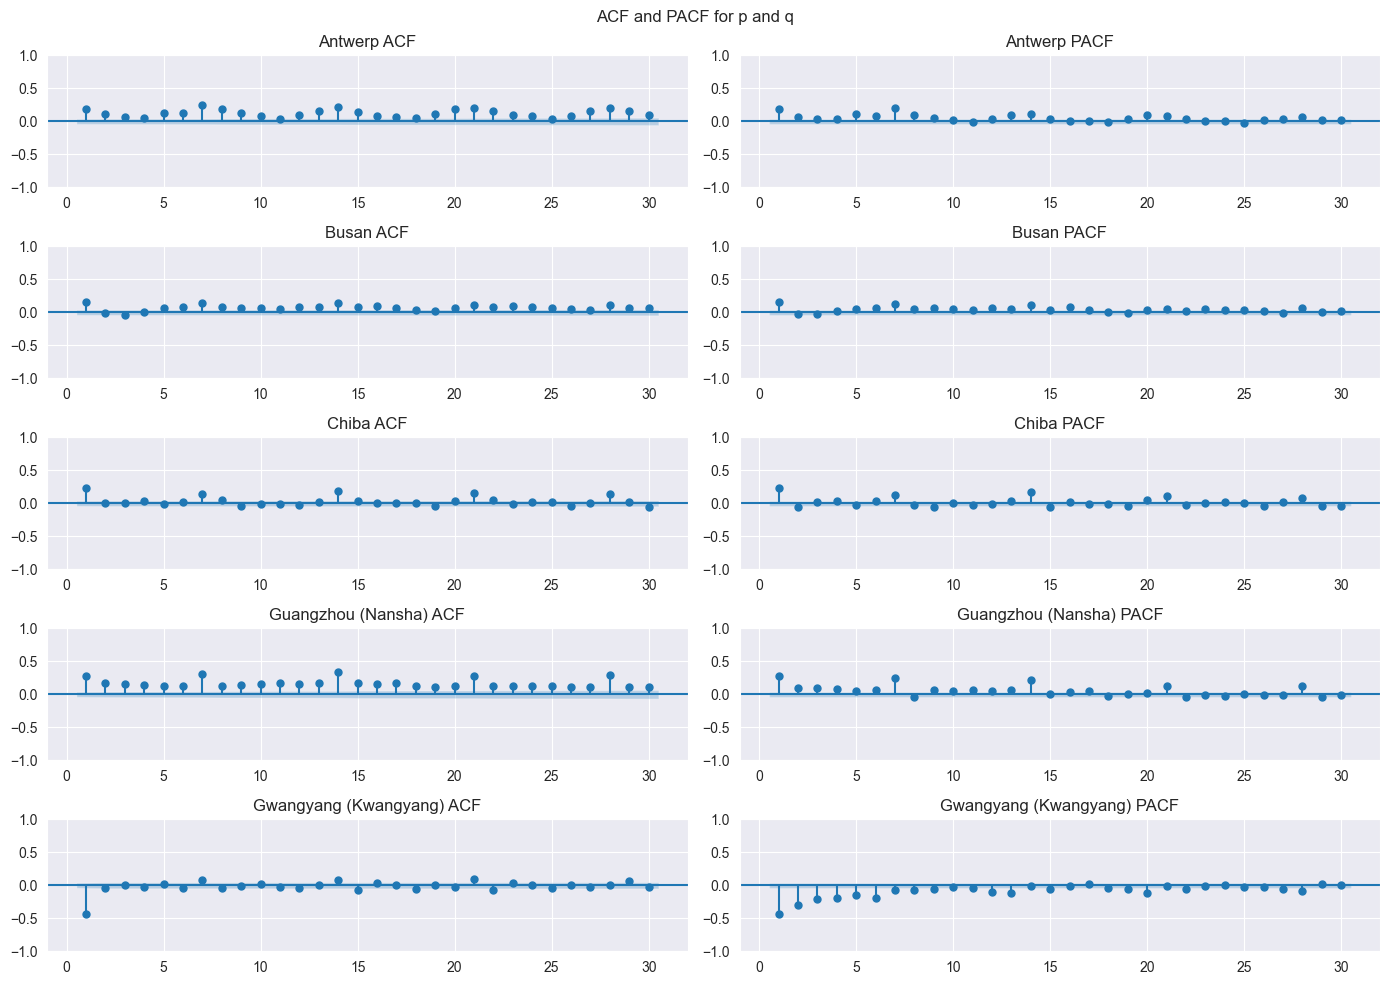

In [6]:
## ACF and PACF plots to identify p and q for ARIMA

fig, axes = plt.subplots(5, 2, figsize=(14,10))
fig.suptitle("ACF and PACF for p and q")

for i, port in enumerate(top_ports[:5]):
    series = port_ts[port].dropna()
    d = adf_df[adf_df['port'] == port]['d'] .values[0]
    plot_series = series.diff().dropna() if d == 1 else series

    plot_acf(plot_series, lags=30, ax=axes[i][0], title=f"{port} ACF", zero=False)
    plot_pacf(plot_series, lags=30, ax=axes[i][1], title=f"{port} PACF", zero=False)

plt.tight_layout()
plt.savefig('../outputs/figures/06_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()

* Port vessel calls don't have strong memory. Yesterday's count doesn't strongly predict today's. This makes sense — vessel arrivals are scheduled by shipping companies days or weeks in advance, so daily fluctuations appear almost random at the 1-day lag level.

In [7]:
TEST_MONTHS = 3
split_date  = port_ts.index.max() - pd.DateOffset(months=TEST_MONTHS)

* Hardcoding p and q.

In [8]:
arima_results_manual = []
fitted_models_manual = {}

for port in top_ports:
    series = port_ts[port].dropna()
    d_val  = adf_df[adf_df['port'] == port]['d'].values[0]
    train  = series[series.index <= split_date]
    test   = series[series.index > split_date]

    p, q = 1, 1

    model    = ARIMA(train, order=(p, d_val, q)).fit()
    forecast = pd.Series(model.forecast(steps=len(test)).values, index=test.index)

    mae  = mean_absolute_error(test, forecast)
    rmse = np.sqrt(mean_squared_error(test, forecast))
    mape = np.mean(np.abs((test - forecast) / test.replace(0, np.nan))) * 100

    fitted_models_manual[port] = {'model': model, 'order': (p, d_val, q)}
    arima_results_manual.append({'port': port, 'p': p, 'd': d_val, 'q': q,
                           'MAE': round(mae,2), 'RMSE': round(rmse,2),
                           'MAPE': round(mape,2)})
    print(f"{port:<25} ARIMA({p},{d_val},{q})  RMSE={rmse:.2f}  MAPE={mape:.1f}%")

manual_df = pd.DataFrame(arima_results_manual)

Antwerp                   ARIMA(1,0,1)  RMSE=10.95  MAPE=17.3%
Busan                     ARIMA(1,0,1)  RMSE=8.16  MAPE=13.6%
Chiba                     ARIMA(1,0,1)  RMSE=10.07  MAPE=29.8%
Guangzhou (Nansha)        ARIMA(1,0,1)  RMSE=5.93  MAPE=17.4%
Gwangyang (Kwangyang)     ARIMA(1,1,1)  RMSE=7.39  MAPE=17.8%
Hong Kong                 ARIMA(1,0,1)  RMSE=6.44  MAPE=13.0%
Kaohsiung                 ARIMA(1,0,1)  RMSE=10.16  MAPE=38.9%
Kobe                      ARIMA(1,0,1)  RMSE=7.83  MAPE=27.3%
Mizushima                 ARIMA(1,0,1)  RMSE=9.11  MAPE=29.5%
Nagoya                    ARIMA(1,0,1)  RMSE=11.35  MAPE=32.7%
Ningbo                    ARIMA(1,1,1)  RMSE=9.59  MAPE=15.1%
Port Klang                ARIMA(1,0,1)  RMSE=5.92  MAPE=13.8%
Qingdao                   ARIMA(1,0,1)  RMSE=5.85  MAPE=15.9%
Rotterdam                 ARIMA(1,0,1)  RMSE=11.70  MAPE=12.4%
Sakai-Semboku             ARIMA(1,0,1)  RMSE=7.42  MAPE=32.6%
Shanghai (Pudong)         ARIMA(1,0,1)  RMSE=16.94  MAPE=13.7%
Si

* Using auto_arima for p and q.

In [9]:
## Fit ARIMA using the parameters suggested by ACF/PACF plots.
print(f"Train: {port_ts.index.min().date()} → {split_date.date()}")
print(f"Test : {(split_date + pd.Timedelta(days=1)).date()} → {port_ts.index.max().date()}\n")

arima_results = []
fitted_models = {}

for port in top_ports:
    series = port_ts[port].dropna()
    d_val  = adf_df[adf_df['port'] == port]['d'].values[0]
    train  = series[series.index <= split_date]
    test   = series[series.index > split_date]

    auto_model = auto_arima(
        train, d=d_val, seasonal=False,                          ## fix d from our ADF test result
        stepwise=True                                            ## no seasonal component for now. Check after fitting
    )
    p, d, q = auto_model.order

    model = ARIMA(train, order=(p, d, q)).fit()
    forecast = pd.Series(model.forecast(steps=len(test)).values, index=test.index)

    mae = mean_absolute_error(test, forecast)
    rmse = np.sqrt(mean_squared_error(test, forecast))
    mape = np.mean(np.abs((test - forecast) / test.replace(0, np.nan))) * 100

    fitted_models[port] = {'model': model, 'order': (p, d, q)}
    arima_results.append({'port': port, 'p': p, 'd': d, 'q': q,
                          'MAE': round(mae,2), 'RMSE': round(rmse,2), 'MAPE': round(mape,2)})
    print(f"{port:<25} ARIMA({p},{d},{q})  RMSE={rmse:.2f}  MAPE={mape:.1f}%")

arima_df = pd.DataFrame(arima_results)

Train: 2019-01-01 → 2025-11-06
Test : 2025-11-07 → 2026-02-06

Antwerp                   ARIMA(1,0,2)  RMSE=10.94  MAPE=17.4%
Busan                     ARIMA(1,0,5)  RMSE=7.98  MAPE=13.1%
Chiba                     ARIMA(0,0,1)  RMSE=10.07  MAPE=29.8%
Guangzhou (Nansha)        ARIMA(1,0,2)  RMSE=5.89  MAPE=17.4%
Gwangyang (Kwangyang)     ARIMA(2,1,2)  RMSE=7.39  MAPE=17.8%
Hong Kong                 ARIMA(1,0,3)  RMSE=6.45  MAPE=13.0%
Kaohsiung                 ARIMA(1,0,5)  RMSE=7.49  MAPE=26.5%
Kobe                      ARIMA(1,0,0)  RMSE=7.83  MAPE=27.3%
Mizushima                 ARIMA(3,0,2)  RMSE=9.02  MAPE=28.2%
Nagoya                    ARIMA(1,0,3)  RMSE=10.93  MAPE=30.9%
Ningbo                    ARIMA(2,1,1)  RMSE=9.59  MAPE=15.2%
Port Klang                ARIMA(2,0,2)  RMSE=5.74  MAPE=13.6%
Qingdao                   ARIMA(3,0,1)  RMSE=5.81  MAPE=16.3%
Rotterdam                 ARIMA(1,0,1)  RMSE=11.70  MAPE=12.4%
Sakai-Semboku             ARIMA(1,0,2)  RMSE=7.30  MAPE=30.0%
Sha

In [10]:
comp = arima_df[['port','RMSE','MAPE']].merge(
    manual_df[['port','RMSE','MAPE']].rename(
        columns={'RMSE':'Manual_RMSE','MAPE':'Manual_MAPE'}),
    on='port'
)
comp.columns = ['port','Auto_RMSE','Auto_MAPE','Manual_RMSE','Manual_MAPE']
comp['Difference_RMSE'] = (comp['Auto_RMSE'] - comp['Manual_RMSE']).round(2)
print(comp.to_string(index=False))

                 port  Auto_RMSE  Auto_MAPE  Manual_RMSE  Manual_MAPE  Difference_RMSE
              Antwerp      10.94      17.35        10.95        17.31            -0.01
                Busan       7.98      13.12         8.16        13.65            -0.18
                Chiba      10.07      29.85        10.07        29.85             0.00
   Guangzhou (Nansha)       5.89      17.38         5.93        17.35            -0.04
Gwangyang (Kwangyang)       7.39      17.77         7.39        17.76             0.00
            Hong Kong       6.45      13.01         6.44        12.99             0.01
            Kaohsiung       7.49      26.47        10.16        38.85            -2.67
                 Kobe       7.83      27.31         7.83        27.31             0.00
            Mizushima       9.02      28.25         9.11        29.53            -0.09
               Nagoya      10.93      30.89        11.35        32.71            -0.42
               Ningbo       9.59      15.15

* ARIMA performs well for stable hubs (Singapore, Rotterdam) but poorly for volatile Japanese ports and Shanghai. This is expected — ARIMA captures autocorrelation structure but cannot anticipate sudden external shocks like policy-driven shutdowns.
* Singapore MAPE=7.2% — excellent, most stable port, Nagoya MAPE=30.9% — poor, volatile Japanese port, Shanghai RMSE=17.06 — highest error, sharp unpredictable spikes.

In [11]:
# ## Yule Walker for estimating p
# from statsmodels.regression.linear_model import yule_walker
#
# yw_orders = {}
#
# for port in top_ports:
#     series = port_ts[port].dropna()
#     d_val  = adf_df[adf_df['port'] == port]['d'].values[0]
#
#     # Use differenced series if d=1
#     s = series.diff().dropna() if d_val == 1 else series
#
#     # Yule-Walker estimates AR coefficients
#     # We try p=1 to p=5 and pick the one with lowest error
#     best_p = 1
#     best_err = np.inf
#
#     for p in range(1, 6):
#         rho, sigma = yule_walker(s, order=p)
#         if sigma < best_err:
#             best_err = sigma
#             best_p   = p
#
#     yw_orders[port] = best_p
#     print(f"{port:<25} p={best_p}")

* Yule Walker keeps giving p=5. Not viable.

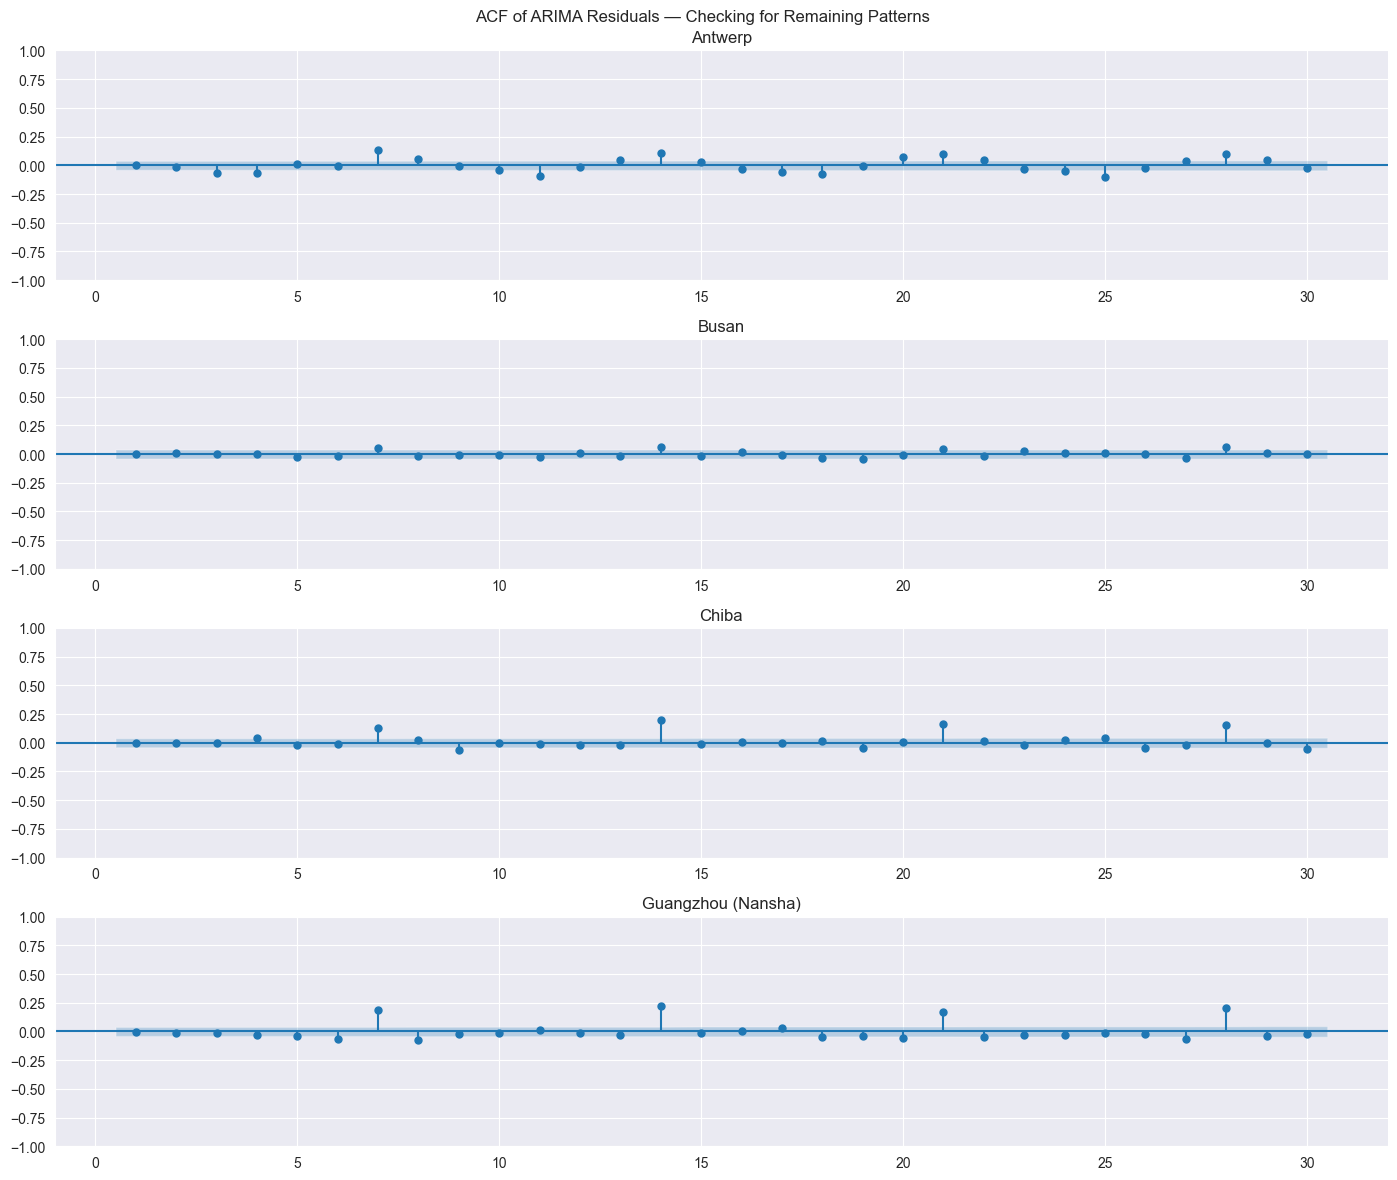

In [12]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12))
fig.suptitle("ACF of ARIMA Residuals — Checking for Remaining Patterns")

for ax, port in zip(axes, top_ports[:4]):
    residuals = fitted_models[port]['model'].resid
    plot_acf(residuals, lags=30, ax=ax, title=f"{port}", zero=False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/figures/07_residual_acf.png', dpi=150, bbox_inches='tight')
plt.show()

* No systematic spikes. No repeating pattern at lag 7 or lag 30. Meaning ARIMA residuals are white noise for these ports. The model captured the available structure. No SARIMA needed.
* Residual ACF plots show that most ports have near-zero autocorrelation in residuals, confirming ARIMA is adequate. Some ports (Chiba, Guangzhou, Singapore, Rotterdam, Kobe) show mild spikes at lag 7 suggesting a weak weekly pattern. This is consistent with weekend vessel call reductions. SARIMA with period=7 could be explored as a refinement

In [13]:
## HoltsWinters
from statsmodels.tsa.holtwinters import ExponentialSmoothing

hw_results = []
hw_models  = {}

for port in top_ports:
    series = port_ts[port].dropna()
    train  = series[series.index <= split_date]
    test   = series[series.index > split_date]

    model = ExponentialSmoothing(
        train, trend='add', seasonal=None,
            initialization_method='estimated'
    ).fit(optimized=True)

    forecast = pd.Series(model.forecast(len(test)).values, index=test.index)

    mae  = mean_absolute_error(test, forecast)
    rmse = np.sqrt(mean_squared_error(test, forecast))
    mape = np.mean(np.abs((test - forecast) / test.replace(0, np.nan))) * 100

    hw_models[port] = forecast
    hw_results.append({'port': port, 'MAE': round(mae,2),
                       'RMSE': round(rmse,2), 'MAPE': round(mape,2)})
    print(f"{port:<25} RMSE={rmse:.2f}  MAPE={mape:.1f}%")

hw_df = pd.DataFrame(hw_results)

Antwerp                   RMSE=10.96  MAPE=17.1%
Busan                     RMSE=7.80  MAPE=12.4%
Chiba                     RMSE=9.86  MAPE=26.8%
Guangzhou (Nansha)        RMSE=5.87  MAPE=18.2%
Gwangyang (Kwangyang)     RMSE=7.50  MAPE=18.4%
Hong Kong                 RMSE=6.51  MAPE=12.7%
Kaohsiung                 RMSE=7.37  MAPE=25.9%
Kobe                      RMSE=7.84  MAPE=27.4%
Mizushima                 RMSE=9.22  MAPE=28.7%
Nagoya                    RMSE=10.72  MAPE=29.4%
Ningbo                    RMSE=9.66  MAPE=15.3%
Port Klang                RMSE=5.97  MAPE=15.1%
Qingdao                   RMSE=5.92  MAPE=16.8%
Rotterdam                 RMSE=11.35  MAPE=11.8%
Sakai-Semboku             RMSE=7.50  MAPE=29.9%
Shanghai (Pudong)         RMSE=18.51  MAPE=15.1%
Singapore                 RMSE=13.98  MAPE=7.2%
Tianjin Xin Gang          RMSE=8.10  MAPE=25.7%
Ulsan                     RMSE=7.65  MAPE=24.9%
Yokohama                  RMSE=9.37  MAPE=27.6%


In [14]:
## Model Comparison Table
comparison = arima_df[['port','RMSE','MAE','MAPE']].copy()
comparison.columns = ['port','ARIMA_RMSE','ARIMA_MAE','ARIMA_MAPE']
comparison = comparison.merge(
    hw_df[['port','RMSE','MAE','MAPE']].rename(columns={
        'RMSE':'HW_RMSE','MAE':'HW_MAE','MAPE':'HW_MAPE'}),
    on='port'
)
comparison['Better'] = np.where(
    comparison['ARIMA_RMSE'] < comparison['HW_RMSE'], 'ARIMA', 'Holt-Winters'
)
print(comparison.to_string(index=False))
print(f"\nARIMA : {(comparison['Better']=='ARIMA').sum()} ports")
print(f"Holt-Winters : {(comparison['Better']=='Holt-Winters').sum()} ports")

                 port  ARIMA_RMSE  ARIMA_MAE  ARIMA_MAPE  HW_RMSE  HW_MAE  HW_MAPE       Better
              Antwerp       10.94       8.52       17.35    10.96    8.57    17.13        ARIMA
                Busan        7.98       6.11       13.12     7.80    5.94    12.44 Holt-Winters
                Chiba       10.07       7.85       29.85     9.86    7.69    26.78 Holt-Winters
   Guangzhou (Nansha)        5.89       4.83       17.38     5.87    4.78    18.16 Holt-Winters
Gwangyang (Kwangyang)        7.39       5.84       17.77     7.50    5.95    18.38        ARIMA
            Hong Kong        6.45       5.22       13.01     6.51    5.22    12.74        ARIMA
            Kaohsiung        7.49       5.32       26.47     7.37    5.25    25.90 Holt-Winters
                 Kobe        7.83       6.01       27.31     7.84    6.01    27.43        ARIMA
            Mizushima        9.02       6.44       28.25     9.22    6.94    28.75        ARIMA
               Nagoya       10.93       

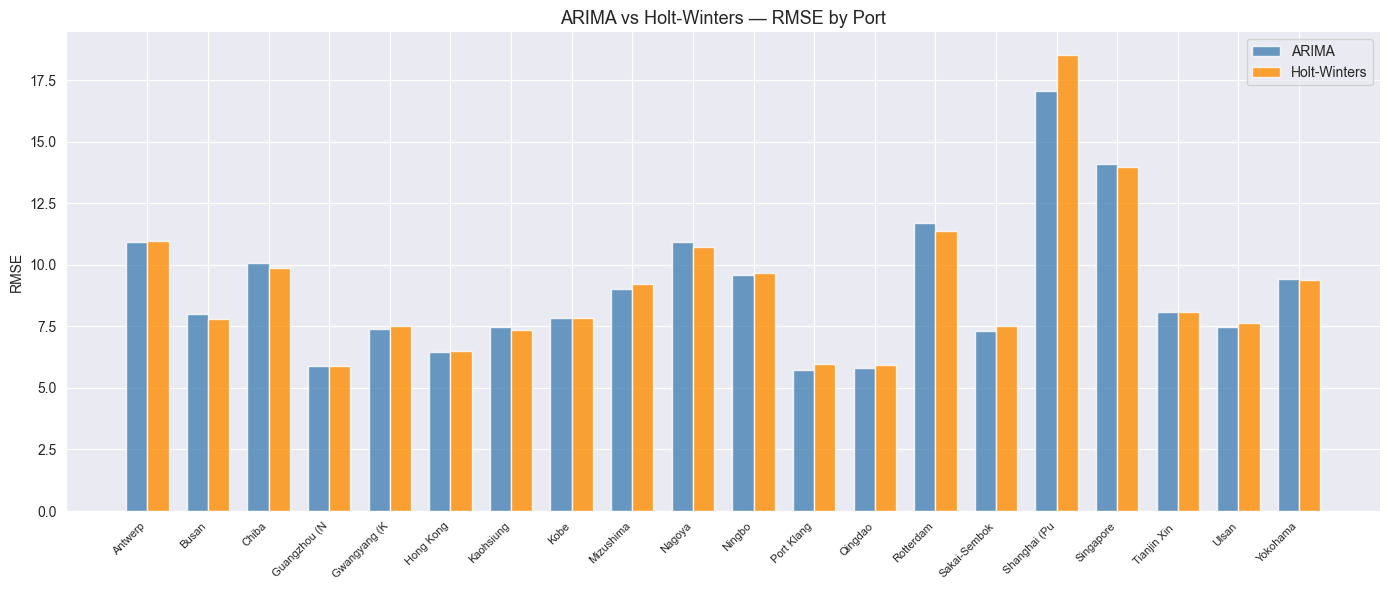

In [15]:
x = np.arange(len(top_ports))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width/2, comparison['ARIMA_RMSE'], width, label='ARIMA', color='steelblue', alpha=0.8)
ax.bar(x + width/2, comparison['HW_RMSE'], width, label='Holt-Winters', color='darkorange', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([p[:12] for p in top_ports], rotation=45, ha='right', fontsize=8)
ax.set_ylabel("RMSE")
ax.set_title("ARIMA vs Holt-Winters — RMSE by Port", fontsize=13)
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../outputs/figures/08_rmse_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

1. Shorter the bar, better the model for that port.
2. Most bar heights are equal. Neither dominates.
3. HW => 8, ARIMA => 12
4. Shanghai has longest bar for both models, meaning it is hardest to forecast.

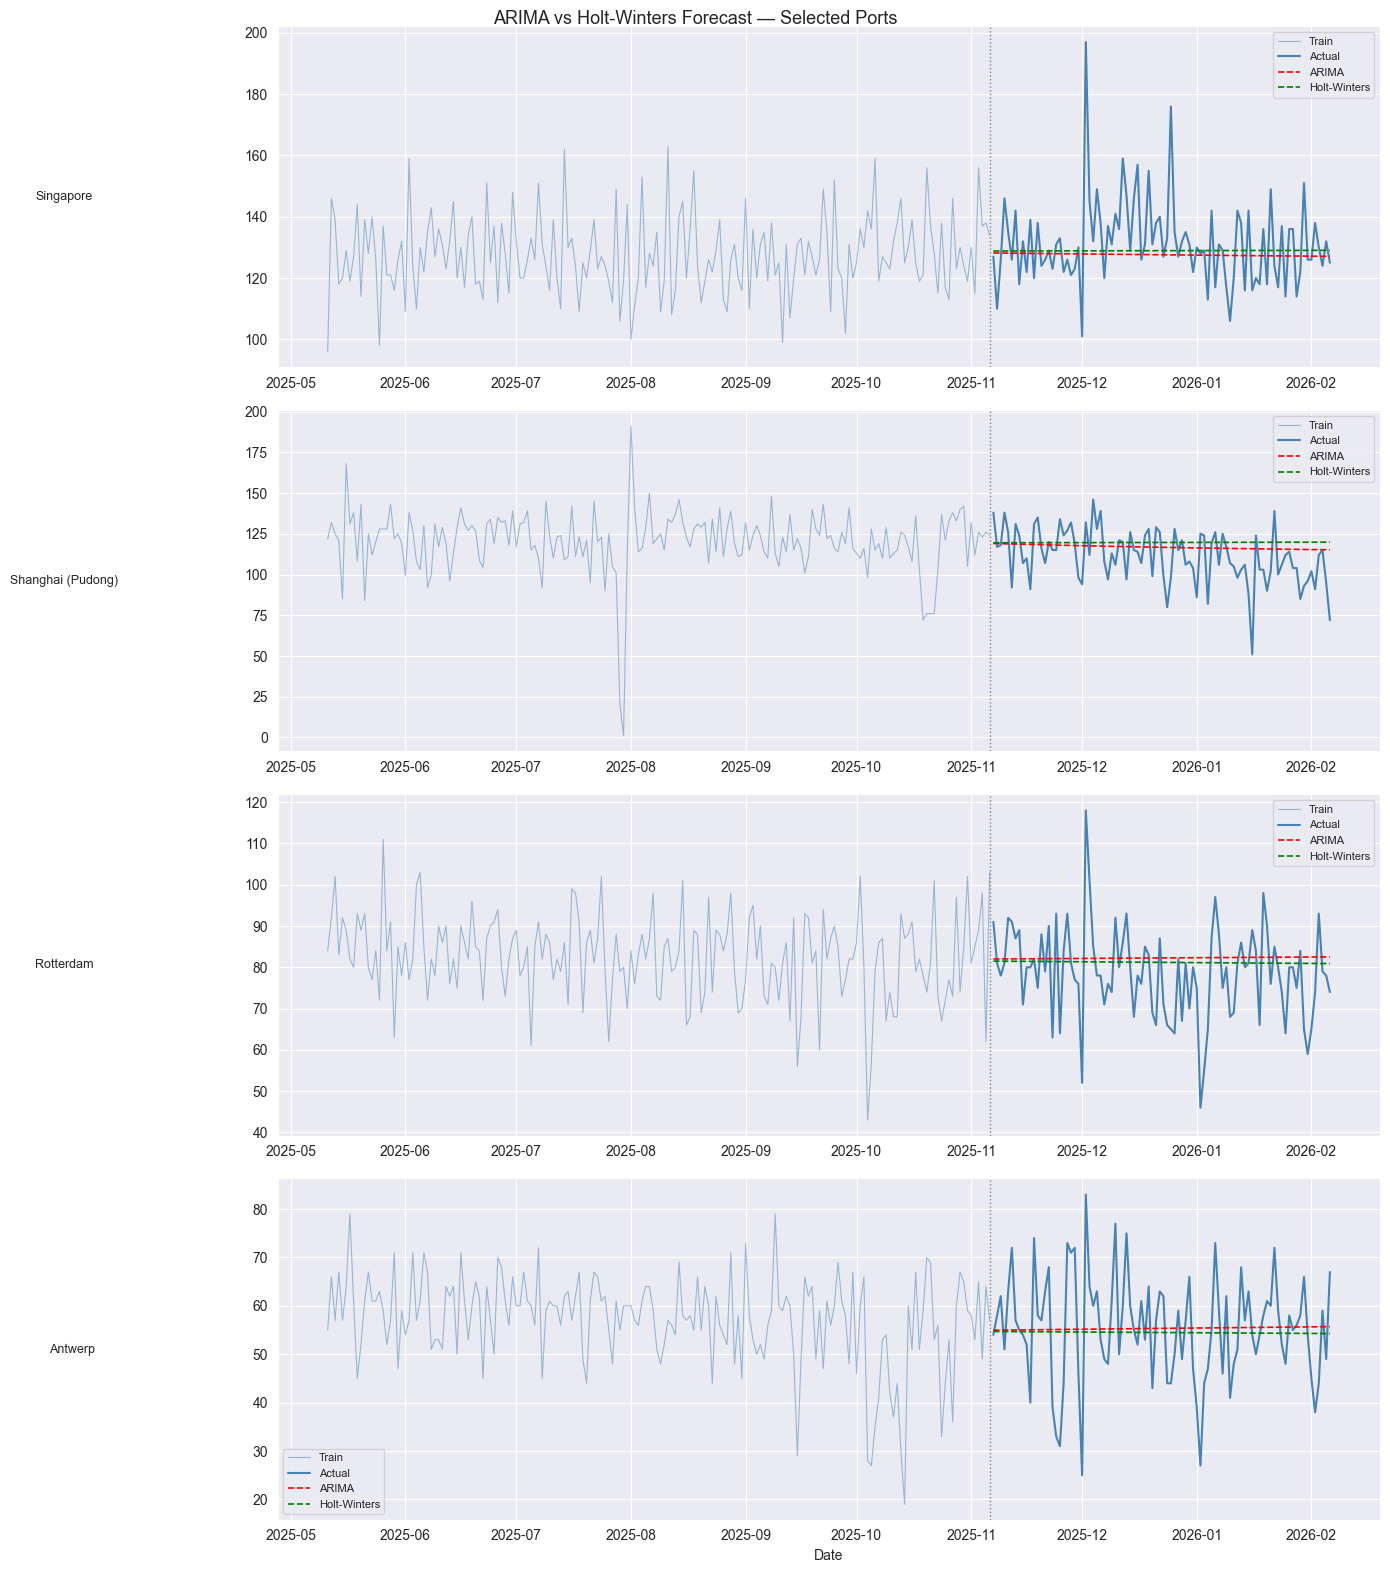

In [16]:
## Forecast vs Actual plot
plot_ports = ['Singapore', 'Shanghai (Pudong)', 'Rotterdam', 'Antwerp']

fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=False)
fig.suptitle("ARIMA vs Holt-Winters Forecast — Selected Ports", fontsize=13)

for ax, port in zip(axes, plot_ports):
    series = port_ts[port].dropna()
    train  = series[series.index <= split_date]
    test   = series[series.index > split_date]

    arima_forecast = pd.Series(
        fitted_models_manual[port]['model'].forecast(steps=len(test)).values,
        index=test.index
    )
    hw_forecast = hw_models[port]

    ax.plot(train[-180:].index, train[-180:].values,
            color='steelblue', linewidth=0.8, alpha=0.5, label='Train')
    ax.plot(test.index, test.values,
            color='steelblue', linewidth=1.5, label='Actual')
    ax.plot(arima_forecast.index, arima_forecast.values,
            color='red', linewidth=1.2, linestyle='--', label='ARIMA')
    ax.plot(hw_forecast.index, hw_forecast.values,
            color='green', linewidth=1.2, linestyle='--', label='Holt-Winters')
    ax.axvline(split_date, color='gray', linestyle=':', linewidth=1)
    ax.set_ylabel(port, fontsize=9, rotation=0, labelpad=130, va='center')
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.savefig('../outputs/figures/09_forecast_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

**Both prediction lines made by both models are flat. Meaning neither model is able to predict when a vessel decides to arrive. So classical models are not working here. Can't catch daily randomness.**

In [17]:
## Cross-Correlation
from scipy import stats

max_lag = 14
results = []

for port_a in top_ports:
    for port_b in top_ports:
        if port_a == port_b:
            continue
        a   = pde_df[port_a].dropna()
        b   = pde_df[port_b].dropna()
        idx = a.index.intersection(b.index)
        a_vals = a.loc[idx].values.astype(float)
        b_vals = b.loc[idx].values.astype(float)

        for lag in range(1, max_lag + 1):
            corr, pval = stats.pearsonr(a_vals[:-lag], b_vals[lag:])
            results.append({'port_a':port_a, 'port_b':port_b,
                            'lag':lag, 'corr':round(corr,4), 'pval':round(pval,4)})

lag_df = pd.DataFrame(results)

# significant = lag_df[(lag_df['pval'] < 0.05) & (lag_df['corr'] > 0.05)]
# significant = significant.sort_values('corr', ascending=False)
#
# print(f"Significant pairs found: {len(significant)}\n")
# print(significant.head(20).to_string(index=False))

from statsmodels.stats.multitest import multipletests

# add right after lag_df is built, before filtering for "significant"
reject, pvals_corrected, _, _ = multipletests(lag_df['pval'], alpha=0.05, method='fdr_bh')
lag_df['pval_corrected'] = pvals_corrected

significant = lag_df[(reject) & (lag_df['corr'] > 0.05)].sort_values('corr', ascending=False)

print(f"Significant pairs found: {len(significant)}")
print(significant.head(20).to_string(index=False))

Significant pairs found: 172
       port_a            port_b  lag   corr  pval  pval_corrected
     Yokohama            Nagoya    1 0.2534   0.0             0.0
        Chiba          Yokohama    1 0.2378   0.0             0.0
       Nagoya              Kobe    1 0.2287   0.0             0.0
        Chiba            Nagoya    1 0.2256   0.0             0.0
    Mizushima            Nagoya    1 0.2233   0.0             0.0
       Nagoya          Yokohama    1 0.2191   0.0             0.0
         Kobe          Yokohama    1 0.2136   0.0             0.0
         Kobe            Nagoya    1 0.2115   0.0             0.0
Sakai-Semboku              Kobe    1 0.2054   0.0             0.0
        Chiba              Kobe    1 0.1985   0.0             0.0
     Yokohama              Kobe    1 0.1975   0.0             0.0
Sakai-Semboku            Nagoya    1 0.1942   0.0             0.0
       Ningbo Shanghai (Pudong)    1 0.1942   0.0             0.0
    Mizushima          Yokohama    1 0.1848   0

* Contagion exists — but it's primarily regional. Disruption spreads between geographically proximate ports on the same trade lane, not across continents. When Yokohama is disrupted, vessels reroute to nearby Nagoya the next day.

In [18]:
arima_df.to_csv('../outputs/processed/arima_results.csv', index=False)
hw_df.to_csv('../outputs/processed/hw_results.csv', index=False)
comparison.to_csv('../outputs/processed/model_comparison.csv', index=False)
lag_df.to_csv('../outputs/processed/cross_correlation.csv', index=False)
significant.to_csv('../outputs/processed/significant_pairs.csv', index=False)

print("All files saved.")

All files saved.
